**Skin Cancer Prediction using CNN**

**Problem Statement:** To build a CNN based model which can accurately detect melanoma. Melanoma is a type of cancer that can be deadly if not detected early. It accounts for 75% of skin cancer deaths. A solution which can evaluate images and alert the dermatologists about the presence of melanoma has the potential to reduce a lot of manual effort needed in diagnosis.

**Importing Libraries**

In [2]:
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, MaxPooling2D, Dropout, BatchNormalization
from skimage import io
import random
import pathlib

**Mount from Drive**

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


**Path for Train and Test Dataset**

In [4]:
data_dir_train = pathlib.Path("/content/gdrive/My Drive/DeepLearning/Train/")
data_dir_test = pathlib.Path('/content/gdrive/My Drive/DeepLearning/Test/')

**Size of Train and Test**

In [5]:
image_count_train = len(list(data_dir_train.glob('*/*.jpg')))
print(image_count_train)
image_count_test = len(list(data_dir_test.glob('*/*.jpg')))
print(image_count_test)

2285
118


**Specifying the Image Dimention**

In [6]:
batch_size = 32
img_height = 180
img_width = 180

**Train and Validation Generation in 80:20 Ratio**

In [7]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(data_dir_train,
                                                               validation_split=0.2,
                                                               subset = 'training',seed=123,batch_size=batch_size,
                                                               image_size = (img_height, img_width))

Found 2285 files belonging to 9 classes.
Using 1828 files for training.


In [8]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(data_dir_train,
                                                             validation_split=0.2,
                                                             subset='validation',seed=123,batch_size=batch_size,
                                                             image_size = (img_height, img_width))

Found 2285 files belonging to 9 classes.
Using 457 files for validation.


**Checking Total Number of Classes**

In [9]:
# Printing class names
class_names = train_ds.class_names
print(class_names)

['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


In [10]:
num_classes = len(class_names)
print('Total no of classes: {}'.format(num_classes))

Total no of classes: 9


**Number of Images Availabe in each Classes**

In [11]:
available_images = []
for cancer in class_names:
  path_str = os.path.join(data_dir_train, cancer)
  cancer_dir = pathlib.Path(path_str)
  content = len(list(cancer_dir.glob("*.jpg")))
  available_images.append(content)
df = pd.DataFrame({'Cancer Type':class_names,
                   'Available Images':available_images})
df_sorted = df.sort_values(by='Available Images', ascending=False)
df_sorted

,Cancer Type,Available Images
5,pigmented benign keratosis,462
3,melanoma,438
1,basal cell carcinoma,376
4,nevus,357
7,squamous cell carcinoma,223
8,vascular lesion,143
0,actinic keratosis,114
2,dermatofibroma,95
6,seborrheic keratosis,77


**Bar Plot of Value Count of Each Classes**

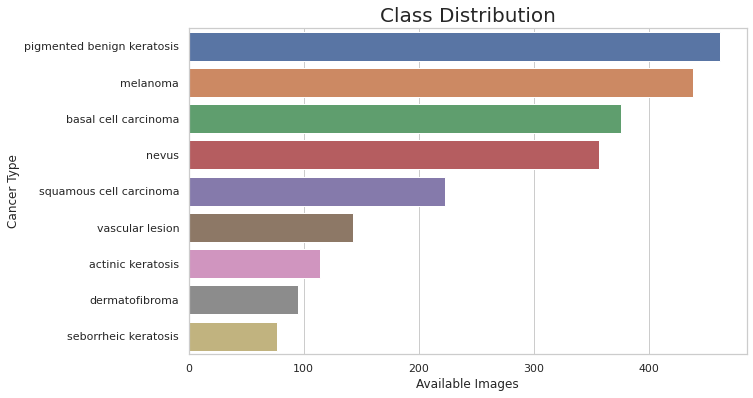

In [12]:
import seaborn as sns
plt.figure(figsize = (10,6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y="Cancer Type", x="Available Images", data=df_sorted)
plt.title("Class Distribution", {'fontsize':20})
plt.show()

**Inferences:**

  1.)Pigmented benign keratosis has the highest no of samples(462) among all other cancer types and thus it dominates other cancer types

  2.)Seborrheic keratosis has the least no of samples(77)

**Visualizing the dataset**

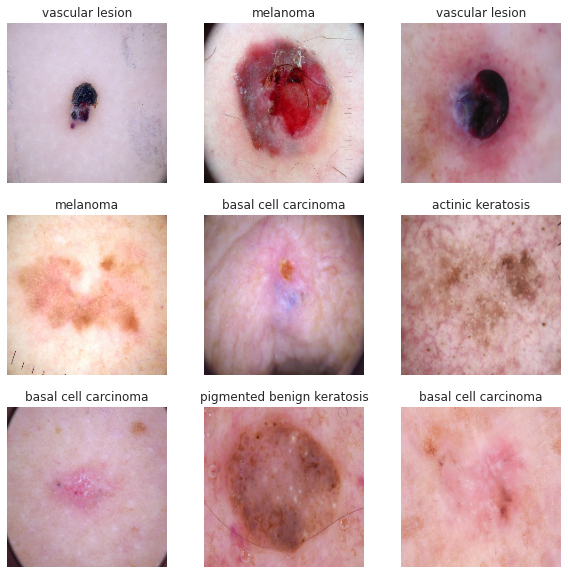

In [13]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(num_classes):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

**Batch Shape Checking**

In [14]:
for image_batch, labels_batch in train_ds:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(32, 180, 180, 3)
(32,)


In [15]:
print(labels_batch)

tf.Tensor([1 4 7 3 1 3 5 3 7 4 3 8 7 8 1 8 4 8 1 6 3 3 1 7 5 4 7 3 7 7 8 5], shape=(32,), dtype=int32)


We can see from above batch labels that we have class labels represented in the form of Sparse matrix form (and not one-hot encoded format)\ So while compiling the model, we have to use the loss function as tf.keras.losses.SparseCategoricalCrossEntropy instead of tf.keras.losses.CategoricalCrossEntropy

**Configuring the dataset for performance**

tf.data API provides tf.data.Dataset.prefetch transformation. Prefetching overlaps preprocessing and model execution in the training step. Thus reduces the time for training.

The no of elements to prefetch should be equal to (or greater than) the no of batches consumed by single training step. tf.data.AUTOTUNE tunes this value dynamically during runtime

**Tuning the Dataset using Autotune**

In [16]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

**CNN Model with 3 Convolutional Layers**

In [17]:
model1 = Sequential([
    layers.experimental.preprocessing.Rescaling(1./255, input_shape=(img_height, img_width, 3)),  # Scaling pixel values between [0,1]
    Conv2D(16, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(64, 3, padding='same', activation = 'relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes)
])

**Compiling with ADAM optimizer and SparceCategoricalCrossentropy Loss**

In [18]:
model1.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer='adam',
              metrics=['accuracy'])

**Summary of 1st CNN Model**

In [19]:
model1.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
rescaling (Rescaling)        (None, 180, 180, 3)       0         
_________________________________________________________________
conv2d (Conv2D)              (None, 180, 180, 16)      448       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 90, 90, 16)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 90, 90, 32)        4640      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 45, 45, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 45, 45, 64)        18496     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 22, 22, 64)        0

**Model Training**

In [20]:
epochs = 20
history = model1.fit(train_ds,
                  validation_data=val_ds,
                  epochs=epochs)

Epoch 1/20
58/58 [==============================] - 333s 1s/step - loss: 1.8299 - accuracy: 0.3315 - val_loss: 1.5825 - val_accuracy: 0.3982
Epoch 2/20
58/58 [==============================] - 1s 20ms/step - loss: 1.5414 - accuracy: 0.4590 - val_loss: 1.7284 - val_accuracy: 0.3873
Epoch 3/20
58/58 [==============================] - 1s 20ms/step - loss: 1.4029 - accuracy: 0.5148 - val_loss: 1.3689 - val_accuracy: 0.5383
Epoch 4/20
58/58 [==============================] - 1s 20ms/step - loss: 1.2733 - accuracy: 0.5492 - val_loss: 1.3642 - val_accuracy: 0.5274
Epoch 5/20
58/58 [==============================] - 1s 20ms/step - loss: 1.2191 - accuracy: 0.5656 - val_loss: 1.5624 - val_accuracy: 0.4333
Epoch 6/20
58/58 [==============================] - 1s 20ms/step - loss: 1.1487 - accuracy: 0.5881 - val_loss: 1.6217 - val_accuracy: 0.4464
Epoch 7/20
58/58 [==============================] - 1s 20ms/step - loss: 1.0155 - accuracy: 0.6433 - val_loss: 1.3384 - val_accuracy: 0.5821
Epoch 8/20
58

**Analysing Result using Loss and Accuracy Plots**

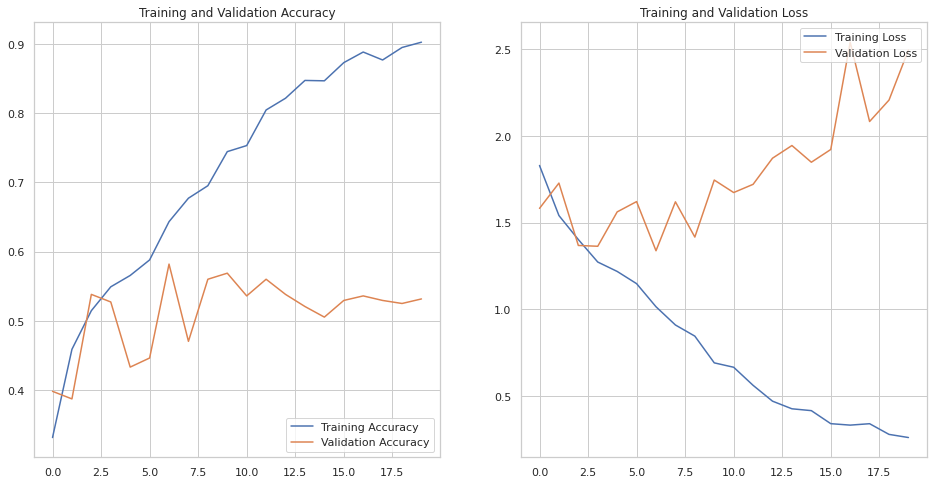

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

**We can see there is Overfitting**

**Inferences:**

1.)The training accuracy is increasing as epochs are increasing, but the validation accuracy is flattening out around 50%

2.)As epochs are increasing the gap between training and validation accuracy is increasing- this is the sign of overfit

3.)In order to reduce the overfit, we implement data augmentation techniques

**Data Augmentation**

We will include data augmentation layer in the model at start. We will use RandomFlip, RandomRotation and RandomZoom methods to do augmentation and generalize the training dataset

In [22]:
augmentation_layer = keras.Sequential([
                                       layers.experimental.preprocessing.RandomFlip(mode='horizontal',input_shape=(img_height,img_width,3)),
                                       layers.experimental.preprocessing.RandomRotation(0.3)])

**Augmented Data**

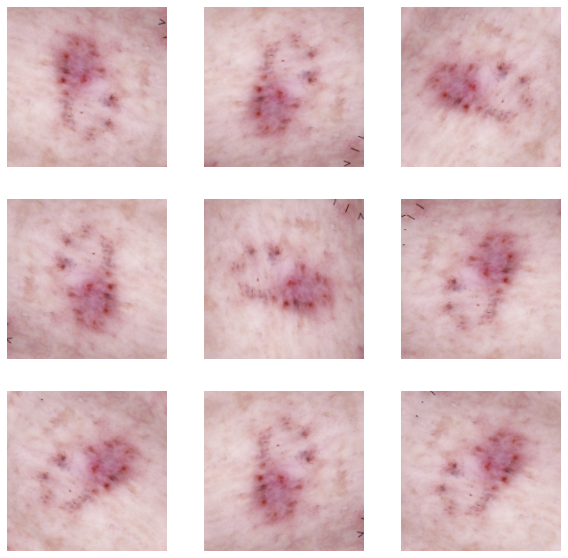

In [23]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = augmentation_layer(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

**CNN Model with 3 Convolutional Layers**

In [24]:
model2 = Sequential([
                    augmentation_layer,
                    layers.experimental.preprocessing.Rescaling(1./255),
                    Conv2D(16, 3, padding='same', activation='relu'),
                    MaxPooling2D(),
                    Conv2D(32, 3, padding='same', activation='relu'),
                    MaxPooling2D(),
                    Conv2D(64, 3, padding='same', activation = 'relu'),
                    MaxPooling2D(),
                    Flatten(),
                    Dense(128, activation='relu'),
                    Dense(num_classes)
])

**Compiling with ADAM optimizer and SparceCategoricalCrossentropy Loss**

In [25]:
model2.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

**Summary of 2nd CNN Model**

In [26]:
model2.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential_1 (Sequential)    (None, 180, 180, 3)       0         
_________________________________________________________________
rescaling_1 (Rescaling)      (None, 180, 180, 3)       0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 180, 180, 16)      448       
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 90, 90, 16)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 90, 90, 32)        4640      
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 45, 45, 32)        0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 45, 45, 64)       

In [27]:
epochs = 20
history = model2.fit(train_ds,
                    validation_data = val_ds,
                    epochs=epochs)

Epoch 1/20
58/58 [==============================] - 2s 25ms/step - loss: 2.1025 - accuracy: 0.2177 - val_loss: 1.9524 - val_accuracy: 0.2691
Epoch 2/20
58/58 [==============================] - 1s 21ms/step - loss: 1.8114 - accuracy: 0.3457 - val_loss: 1.7021 - val_accuracy: 0.3982
Epoch 3/20
58/58 [==============================] - 1s 21ms/step - loss: 1.5619 - accuracy: 0.4650 - val_loss: 1.5132 - val_accuracy: 0.4705
Epoch 4/20
58/58 [==============================] - 1s 21ms/step - loss: 1.4775 - accuracy: 0.4923 - val_loss: 1.4223 - val_accuracy: 0.5164
Epoch 5/20
58/58 [==============================] - 1s 21ms/step - loss: 1.4689 - accuracy: 0.4721 - val_loss: 1.4991 - val_accuracy: 0.4836
Epoch 6/20
58/58 [==============================] - 1s 21ms/step - loss: 1.4043 - accuracy: 0.4940 - val_loss: 1.4054 - val_accuracy: 0.5164
Epoch 7/20
58/58 [==============================] - 1s 21ms/step - loss: 1.3400 - accuracy: 0.5274 - val_loss: 1.4187 - val_accuracy: 0.5098
Epoch 8/20
58

**Analysing Result using Loss and Accuracy Plots**

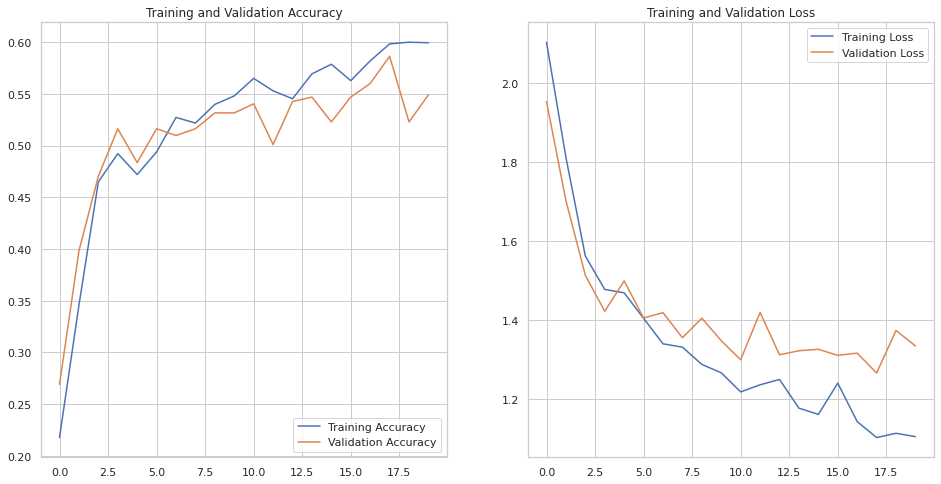

In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

***The Overfitting Issue Solved***

**Inferences:**

Here we can see that the overfitting has been reduced as we have used data augmentation techniques

**Installing Augmentor Library**

In [29]:
!pip install Augmentor

In [30]:
class_names

['actinic keratosis',
 'basal cell carcinoma',
 'dermatofibroma',
 'melanoma',
 'nevus',
 'pigmented benign keratosis',
 'seborrheic keratosis',
 'squamous cell carcinoma',
 'vascular lesion']

**Handling Data Imbalance issues for each classes using Augmentor Library**

**Making 250 images in total for each classes**

In [31]:
path_to_training_dataset='/content/gdrive/My Drive/DeepLearning/Train/'
import Augmentor
for i in class_names:
    p = Augmentor.Pipeline(path_to_training_dataset + i)
    p.rotate(probability=0.6, max_left_rotation=10, max_right_rotation=10)
    p.flip_left_right(probability=0.4)
    p.sample(250) ## We are adding 250 samples per class to make sure that none of the classes are sparse.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7FE162183F90>:   0%|          | 1/250 [00:00<00:30,  8.03 Samples/s]

Initialised with 114 image(s) found.
Output directory set to /content/gdrive/My Drive/DeepLearning/Train/actinic keratosis/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7FE16217CD10>: 100%|██████████| 250/250 [00:08<00:00, 29.05 Samples/s]
Executing Pipeline:   0%|          | 0/250 [00:00<?, ? Samples/s]

Initialised with 376 image(s) found.
Output directory set to /content/gdrive/My Drive/DeepLearning/Train/basal cell carcinoma/output.

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x7FE16213B250>: 100%|██████████| 250/250 [00:08<00:00, 27.90 Samples/s]
Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7FE162190950>:   0%|          | 1/250 [00:00<00:26,  9.23 Samples/s]

...

Processing <PIL.Image.Image image mode=RGB size=1024x768 at 0x7FE186EAE210>: 100%|██████████| 250/250 [00:19<00:00, 12.87 Samples/s]
Executing Pipeline:   0%|          | 0/250 [00:00<?, ? Samples/s]

Initialised with 223 image(s) found.
Output directory set to /content/gdrive/My Drive/DeepLearning/Train/squamous cell carcinoma/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7FE238BEBB50>: 100%|██████████| 250/250 [00:09<00:00, 27.46 Samples/s]
Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x7FE162168650>:   0%|          | 0/250 [00:00<?, ? Samples/s]

Initialised with 143 image(s) found.
Output directory set to /content/gdrive/My Drive/DeepLearning/Train/vascular lesion/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7FE1620E5F90>: 100%|██████████| 250/250 [00:08<00:00, 28.28 Samples/s]


In [32]:
image_count_train = len(list(data_dir_train.glob('*/output/*.jpg')))
print(image_count_train)

2250


**Total of 2250 augmented images of all 9 classes**

In [33]:
# Path list of all the Augmented Images in /output folder in each class folder
path_list = [x for x in glob.glob(os.path.join(data_dir_train, '*','output', '*.jpg'))]

In [34]:
# Label corresponding to each path in path list 
label_list_new = [os.path.basename(os.path.dirname(os.path.dirname(y))) for y in glob.glob(os.path.join(data_dir_train, '*','output', '*.jpg'))]

**Making a DataFrame**

In [35]:
df_path_label = pd.DataFrame()
df_path_label['Path'] = path_list
df_path_label['Label'] = label_list_new

In [36]:
df_path_label.head()

,Path,Label
0,/content/gdrive/My Drive/DeepLearning/Train/ac...,actinic keratosis
1,/content/gdrive/My Drive/DeepLearning/Train/ac...,actinic keratosis
2,/content/gdrive/My Drive/DeepLearning/Train/ac...,actinic keratosis
3,/content/gdrive/My Drive/DeepLearning/Train/ac...,actinic keratosis
4,/content/gdrive/My Drive/DeepLearning/Train/ac...,actinic keratosis


**Saving the Dataset for Emergency Cases**

In [37]:
df_path_label.to_csv("path_label_data.csv")

In [38]:
df_path_label = pd.read_csv("path_label_data.csv")

**Equal Number of Images for Each Class**

In [39]:
df_path_label['Label'].value_counts()

dermatofibroma                250
pigmented benign keratosis    250
basal cell carcinoma          250
actinic keratosis             250
seborrheic keratosis          250
squamous cell carcinoma       250
nevus                         250
vascular lesion               250
melanoma                      250
Name: Label, dtype: int64

**Making dataframe of Path:Label from the original dataset of images used earlier**

In [40]:
path_list_original = [x for x in list(data_dir_train.glob('*/*.jpg'))]
label_list_original = [os.path.basename(os.path.dirname(y)) for y in list(data_dir_train.glob('*/*.jpg'))]

df_path_label_original = pd.DataFrame()
df_path_label_original['Path'] = path_list_original
df_path_label_original['Label'] = label_list_original

df_path_label_original.head()

,Path,Label
0,/content/gdrive/My Drive/DeepLearning/Train/ac...,actinic keratosis
1,/content/gdrive/My Drive/DeepLearning/Train/ac...,actinic keratosis
2,/content/gdrive/My Drive/DeepLearning/Train/ac...,actinic keratosis
3,/content/gdrive/My Drive/DeepLearning/Train/ac...,actinic keratosis
4,/content/gdrive/My Drive/DeepLearning/Train/ac...,actinic keratosis


**Original Class distribution**

In [41]:
df_path_label_original['Label'].value_counts()

pigmented benign keratosis    462
melanoma                      438
basal cell carcinoma          376
nevus                         357
squamous cell carcinoma       223
vascular lesion               143
actinic keratosis             114
dermatofibroma                 95
seborrheic keratosis           77
Name: Label, dtype: int64

Adding two dataframes to create a single dataframe containing original and Augmented images for our analysis

In [42]:
df_path_label_all = pd.concat([df_path_label, df_path_label_original])
df_path_label_all['Path'] = df_path_label_all['Path'].astype('str')
df_path_label_all['Label'].value_counts()

pigmented benign keratosis    712
melanoma                      688
basal cell carcinoma          626
nevus                         607
squamous cell carcinoma       473
vascular lesion               393
actinic keratosis             364
dermatofibroma                345
seborrheic keratosis          327
Name: Label, dtype: int64

**Calling Image Data Generator**

In [43]:
from keras_preprocessing.image import ImageDataGenerator


In [44]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_dataframe(dataframe = df_path_label_all, directory = None,
                                              x_col = 'Path', y_col = 'Label',target_size = (img_height, img_width),
                                              class_mode='sparse', batch_size = 32, subset = 'training')

val_generator = datagen.flow_from_dataframe(dataframe = df_path_label_all, directory = None,
                                              x_col = 'Path', y_col = 'Label',target_size = (img_height, img_width),
                                              class_mode='sparse', batch_size = 32, subset = 'validation')

Found 3628 validated image filenames belonging to 9 classes.
Found 907 validated image filenames belonging to 9 classes.


**We will use callbacks function on Keras library to reduce the learning rate when validation loss is becoming stagnant**

In [45]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.001)

1.)We are monitoring val_loss parameter

2.)When LR becoming stagnant, we reduce it by factor specified. i.e new LR = old LR * factor

3.)patience = 2 implies we would wait for 2 epochs to update the LR

4.)Minimum LR can be equal to 0.001

**CNN Model with 2 convolutional layers**

In [46]:
model3 = tf.keras.models.Sequential([                                   
                    Conv2D(16, 3, padding='same', activation='relu'),                    
                    MaxPooling2D(),
                    Conv2D(32, 3, padding='same', activation='relu'),
                    BatchNormalization(),
                    MaxPooling2D(),                    
                    Dropout(0.25),
                    Flatten(),
                    Dense(64, activation='relu'),
                    Dense(num_classes)
])

**Compiling with ADAM optimizer and SparceCategoricalCrossentropy Loss**

In [47]:
model3.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [48]:
epochs = 30
history = model3.fit(train_generator,
                    validation_data = val_generator,
                    epochs=epochs, callbacks=[reduce_lr])

Epoch 1/30
114/114 [==============================] - 55s 481ms/step - loss: 2.3521 - accuracy: 0.3134 - val_loss: 2.1595 - val_accuracy: 0.2117
Epoch 2/30
114/114 [==============================] - 54s 476ms/step - loss: 1.6176 - accuracy: 0.4063 - val_loss: 2.1902 - val_accuracy: 0.1985
Epoch 3/30
114/114 [==============================] - 55s 482ms/step - loss: 1.4461 - accuracy: 0.4507 - val_loss: 2.4165 - val_accuracy: 0.2767
Epoch 4/30
114/114 [==============================] - 53s 469ms/step - loss: 1.3320 - accuracy: 0.5074 - val_loss: 1.9540 - val_accuracy: 0.3131
Epoch 5/30
114/114 [==============================] - 54s 471ms/step - loss: 1.2157 - accuracy: 0.5413 - val_loss: 3.6691 - val_accuracy: 0.2536
Epoch 6/30
114/114 [==============================] - 53s 468ms/step - loss: 1.1728 - accuracy: 0.5560 - val_loss: 2.2799 - val_accuracy: 0.1676
Epoch 7/30
114/114 [==============================] - 54s 474ms/step - loss: 1.0734 - accuracy: 0.5965 - val_loss: 2.0962 - val_ac

**Analysing Result using Loss and Accuracy Plots**

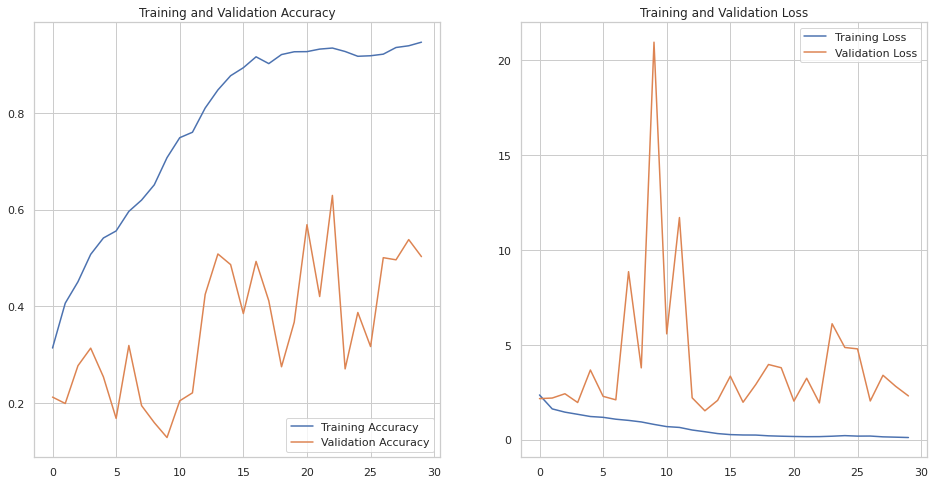

In [49]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

**Augmentor library doesn't seem to provide a good model fit, instead it is contributing overfit**

The highest accuracy achieved is approximately 60% (accuracy: 0.5996)

To furthur increase the validation accuracy or reduce the overfit,  Transfer Learning by using pre-trained models like ResNet, GoogleNet or VGGNet should be used

**We will use callbacks function on Keras library to reduce the learning rate when validation loss is becoming stagnant**

In [50]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.01)

1.)We are monitoring val_loss parameter

2.)When LR becoming stagnant, we reduce it by factor specified. i.e new LR = old LR * factor

3.)patience = 2 implies we would wait for 2 epochs to update the LR

4.)Minimum LR can be equal to 0.01

**CNN Model with 2 convolutional layers**

In [51]:
model4 = tf.keras.models.Sequential([                                   
                    Conv2D(16, 3, padding='same', activation='relu'),                    
                    MaxPooling2D(),
                    Conv2D(32, 3, padding='same', activation='relu'),
                    BatchNormalization(),
                    MaxPooling2D(),                    
                    Dropout(0.25),
                    Flatten(),
                    Dense(64, activation='relu'),
                    Dense(num_classes)
])

**Compiling with ADAM optimizer and SparceCategoricalCrossentropy Loss**

In [52]:
model4.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [55]:
epochs = 40
history = model4.fit(train_generator,
                    validation_data = val_generator,
                    epochs=epochs, callbacks=[reduce_lr])

Epoch 1/40
114/114 [==============================] - 54s 475ms/step - loss: 0.3389 - accuracy: 0.8809 - val_loss: 2.6377 - val_accuracy: 0.4289
Epoch 2/40
114/114 [==============================] - 54s 470ms/step - loss: 0.2807 - accuracy: 0.8942 - val_loss: 2.9497 - val_accuracy: 0.3936
Epoch 3/40
114/114 [==============================] - 53s 470ms/step - loss: 0.3013 - accuracy: 0.8875 - val_loss: 2.1551 - val_accuracy: 0.4972
Epoch 4/40
114/114 [==============================] - 54s 470ms/step - loss: 0.2826 - accuracy: 0.8922 - val_loss: 2.6836 - val_accuracy: 0.4972
Epoch 5/40
114/114 [==============================] - 54s 475ms/step - loss: 0.2211 - accuracy: 0.9135 - val_loss: 3.3868 - val_accuracy: 0.3859
Epoch 6/40
114/114 [==============================] - 56s 489ms/step - loss: 0.1986 - accuracy: 0.9203 - val_loss: 3.8402 - val_accuracy: 0.4057
Epoch 7/40
114/114 [==============================] - 54s 477ms/step - loss: 0.1971 - accuracy: 0.9209 - val_loss: 4.6679 - val_ac

**Analysing Result using Loss and Accuracy Plots**

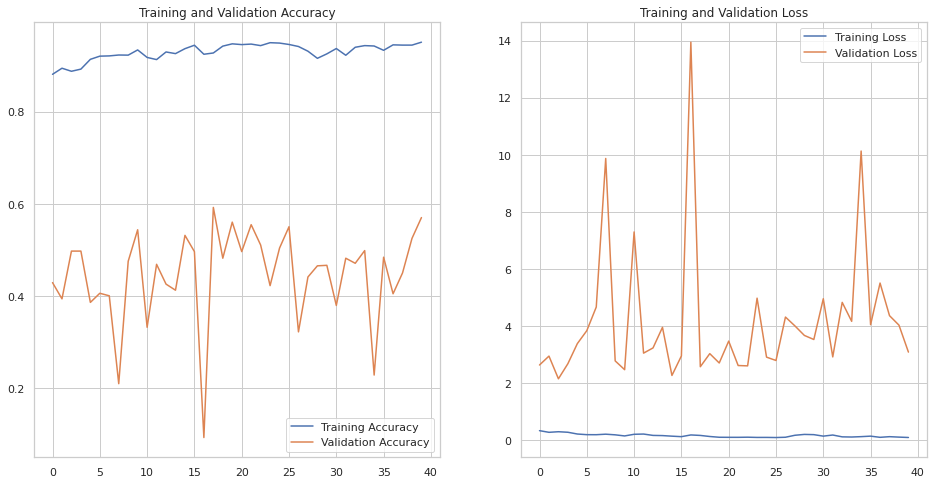

In [56]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

**Model is still overfitting**

**We will use callbacks function on Keras library to reduce the learning rate when validation loss is becoming stagnant**

1.)We are monitoring val_loss parameter

2.)When LR becoming stagnant, we reduce it by factor specified. i.e new LR = old LR * factor

3.)patience = 2 implies we would wait for 2 epochs to update the LR

4.)Minimum LR can be equal to 0.01

**CNN Model with 2 convolutional layers**

In [59]:
model5 = tf.keras.models.Sequential([                                   
                    Conv2D(16, 3, padding='same', activation='relu'),                    
                    MaxPooling2D(),
                    Conv2D(32, 3, padding='same', activation='relu'),
                    BatchNormalization(),
                    MaxPooling2D(),                    
                    Dropout(0.75),
                    Flatten(),
                    Dense(64, activation='relu'),
                    Dense(num_classes)
])

**Compiling with ADAM optimizer and SparceCategoricalCrossentropy Loss**

In [60]:
model5.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [62]:
epochs = 40
history = model5.fit(train_generator,
                    validation_data = val_generator,
                    epochs=epochs, callbacks=[reduce_lr])

Epoch 1/40
114/114 [==============================] - 53s 469ms/step - loss: 1.7550 - accuracy: 0.3443 - val_loss: 2.0956 - val_accuracy: 0.1874
Epoch 2/40
114/114 [==============================] - 53s 464ms/step - loss: 1.5470 - accuracy: 0.4236 - val_loss: 2.0226 - val_accuracy: 0.3727
Epoch 3/40
114/114 [==============================] - 53s 464ms/step - loss: 1.4386 - accuracy: 0.4620 - val_loss: 2.2583 - val_accuracy: 0.3219
Epoch 4/40
114/114 [==============================] - 54s 471ms/step - loss: 1.3278 - accuracy: 0.5074 - val_loss: 2.1984 - val_accuracy: 0.0276
Epoch 5/40
114/114 [==============================] - 53s 468ms/step - loss: 1.2259 - accuracy: 0.5466 - val_loss: 2.5947 - val_accuracy: 0.2481
Epoch 6/40
114/114 [==============================] - 53s 463ms/step - loss: 1.1429 - accuracy: 0.5821 - val_loss: 3.3514 - val_accuracy: 0.2260
Epoch 7/40
114/114 [==============================] - 53s 465ms/step - loss: 1.0212 - accuracy: 0.6191 - val_loss: 3.5545 - val_ac

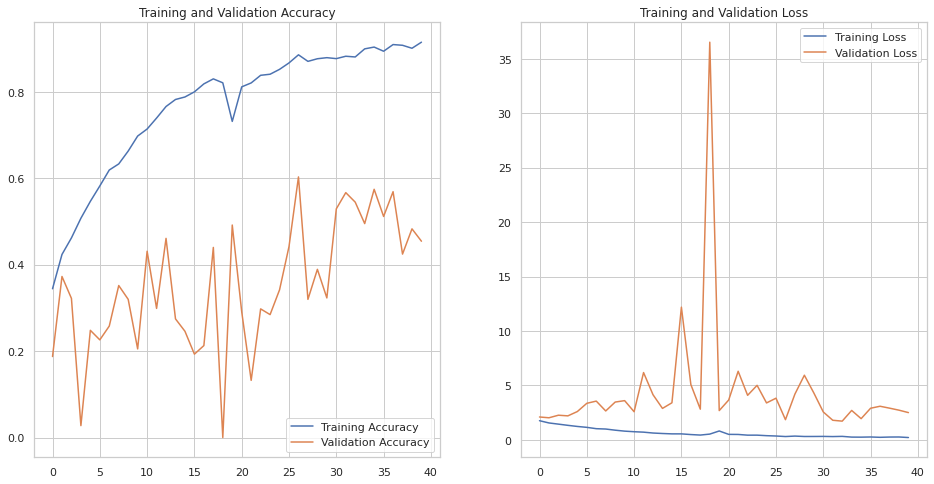

In [63]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Slight improvement in the model